# Proyek Machine Learning  Predictive Analytics: Stroke Prediction Dataset
- **Nama:** Septi Isdayanna
- **Email:** septiisdaynnaa@gmail.com
- **ID Dicoding:** septi_isdayanna

## Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay, roc_curve, auc

## Data Preparation

### Data Loading

In [2]:
# Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"septiisdayanna","key":"196ad5d1a886942d9a9490ecb8f2215e"}'}

In [3]:
# Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dan extract dataset
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset
!unzip -q stroke-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
  0% 0.00/67.4k [00:00<?, ?B/s]
100% 67.4k/67.4k [00:00<00:00, 312MB/s]


In [4]:
# Baca file CSV
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Testing
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


#### **Insight**
- Ada 5110 baris (records atau jumlah pengamatan) dalam dataset.
- Terdapat 12 kolom yaitu: id, gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke

### Assessing Data

In [5]:
# Menampilkan informasi tentang dataset, termasuk jumlah baris, kolom, tipe data, dan jumlah nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
# Memeriksa jumlah nilai yang hilang di setiap fitur
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [7]:
# Menampilkan statistik deskriptif dari dataset untuk fitur numerik
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# Menampilkan statistik deskriptif dari dataset untuk fitur kategorikal
df.describe(include='object')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [9]:
# Mengidentifikasi duplikat data
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


#### **Insight**
- Terdapat 5 kolom dengan tipe object, yaitu: gender, ever_married, work_type, Residence_type, smoking_status. Kolom ini merupakan categorical features (fitur non-numerik).
- Terdapat 3 kolom numerik dengan tipe data float64 yaitu: age, avg_glucose_level, bmi. Ini merupakan fitur numerik yang merupakan hasil pengukuran secara fisik.
- Terdapat 4 kolom numerik dengan tipe data int64, yaitu: id, hypertension, heart_disease, stroke. Kolom stroke merupakan target fitur kita.
- Hanya fitur bmi yang memiliki missing value sebanyak 201
- Dari hasil deskriptif statistik tersebut, rata-rata usia pasien adalah 43,2 tahun, dengan BMI 28,9 dan kadar glukosa darah 106,1 mg/dL, dan juga mayoritas pasien adalah perempuan.
- Dataset tersebut tidak memiliki data yang duplikat.

## Exploratory Data Analysis (EDA)

In [10]:
# Memisahkan fitur kategori dan numerik untuk memudahkan analisis
num_features = df.select_dtypes(include=[np.number])
cat_features = df.select_dtypes(include='object')

### Univariate analysis

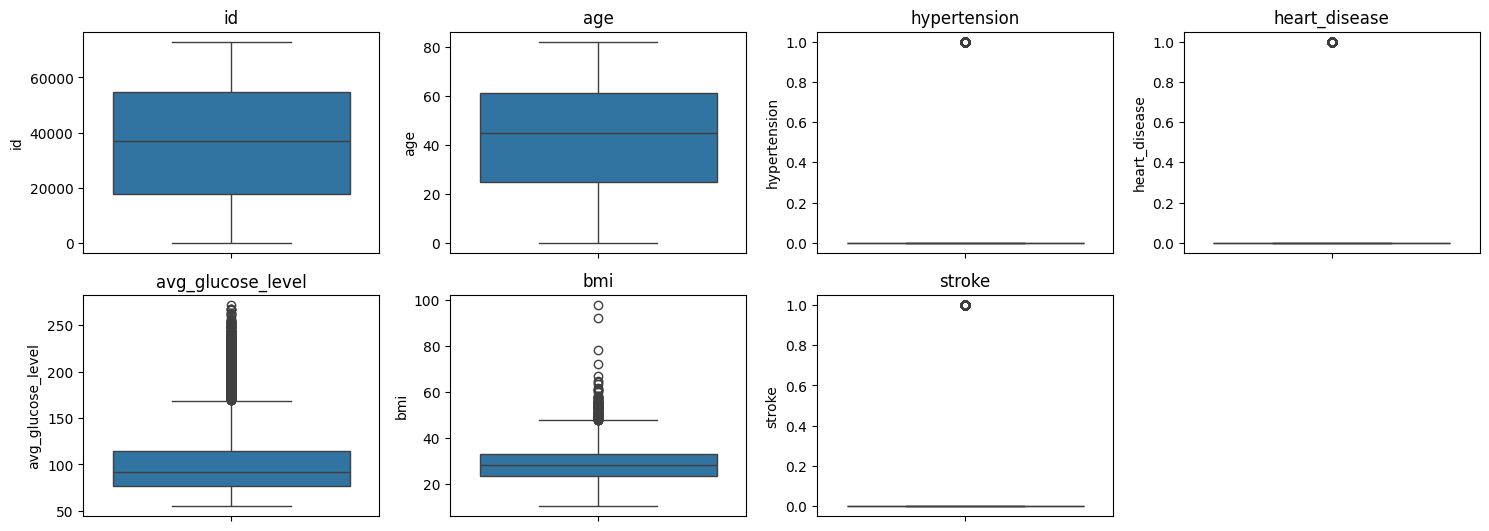

In [11]:
# Mengidentifikasi outlier untuk fitur numerik
plt.figure(figsize=(15, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()


=== Univariate Analisis: gender ===
        jumlah sampel  persentase (%)
gender                               
Female           2994            58.6
Male             2115            41.4
Other               1             0.0


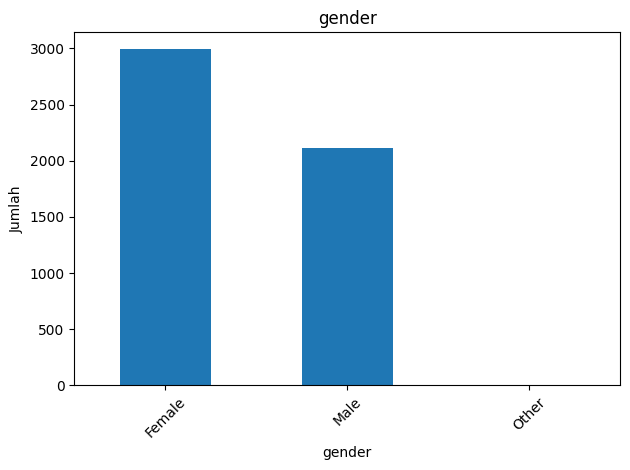


=== Univariate Analisis: ever_married ===
              jumlah sampel  persentase (%)
ever_married                               
Yes                    3353            65.6
No                     1757            34.4


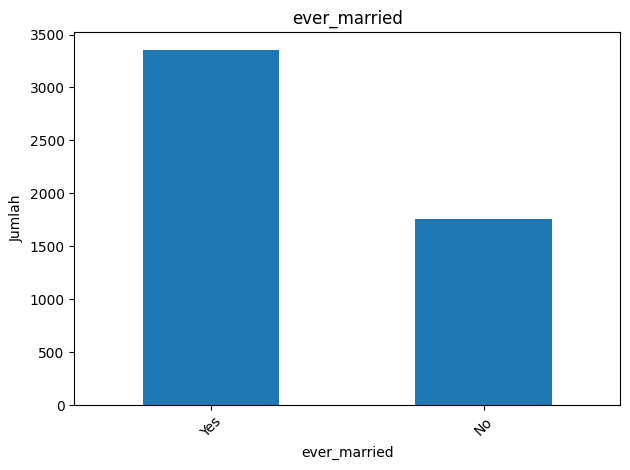


=== Univariate Analisis: work_type ===
               jumlah sampel  persentase (%)
work_type                                   
Private                 2925            57.2
Self-employed            819            16.0
children                 687            13.4
Govt_job                 657            12.9
Never_worked              22             0.4


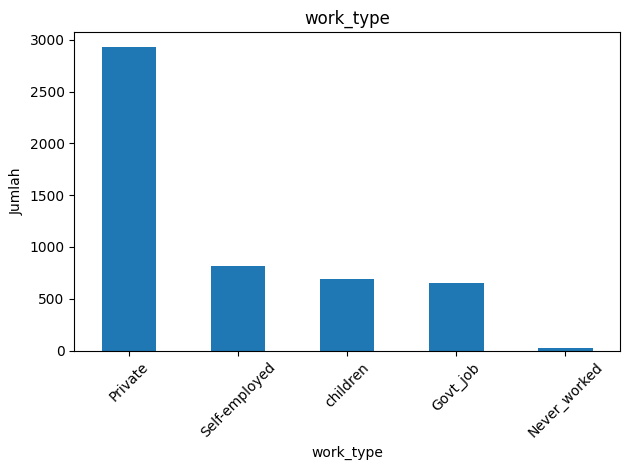


=== Univariate Analisis: Residence_type ===
                jumlah sampel  persentase (%)
Residence_type                               
Urban                    2596            50.8
Rural                    2514            49.2


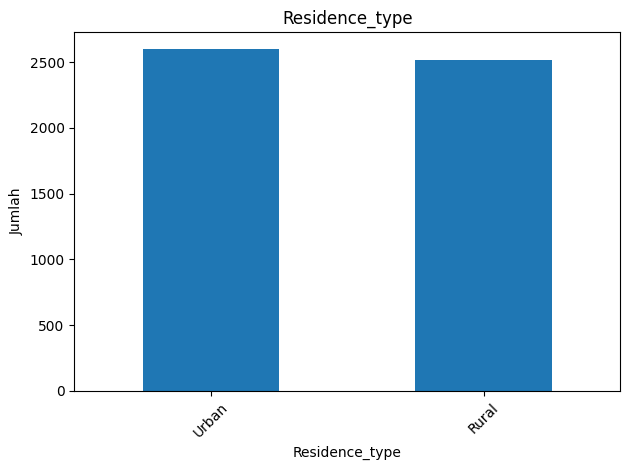


=== Univariate Analisis: smoking_status ===
                 jumlah sampel  persentase (%)
smoking_status                                
never smoked              1892            37.0
Unknown                   1544            30.2
formerly smoked            885            17.3
smokes                     789            15.4


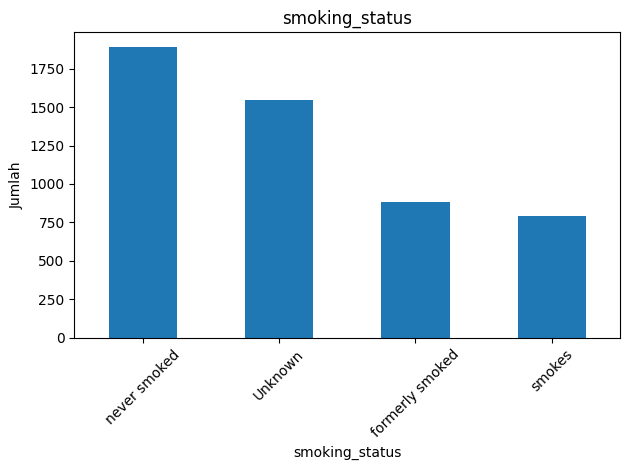

In [12]:
# Distribusi fitur kategorikal
for feature in cat_features:
    print(f"\n=== Univariate Analisis: {feature} ===")
    count = df[feature].value_counts()
    percent = 100 * df[feature].value_counts(normalize=True)
    summary_df = pd.DataFrame({'jumlah sampel': count, 'persentase (%)': percent.round(1)})
    print(summary_df)

    # Visualisasi bar chart
    count.plot(kind='bar', title=feature)
    plt.ylabel("Jumlah")
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

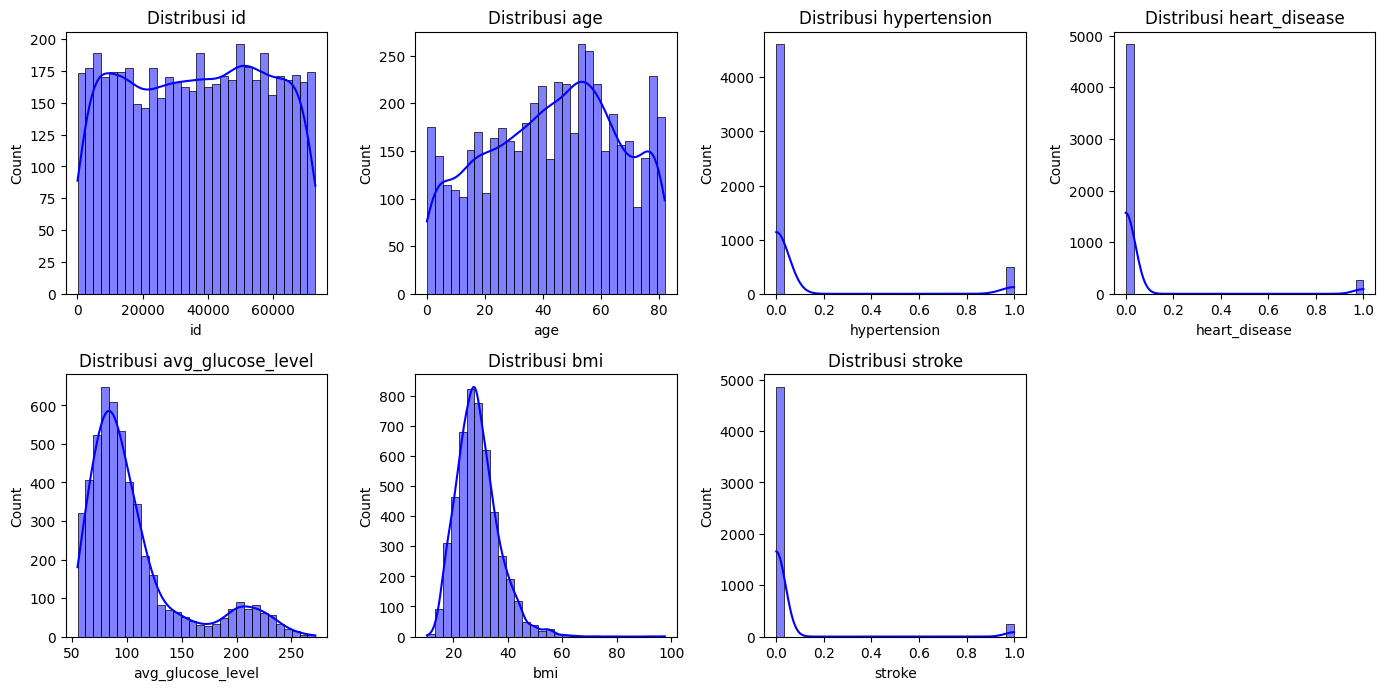

In [13]:
# Distribusi fitur numerik
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

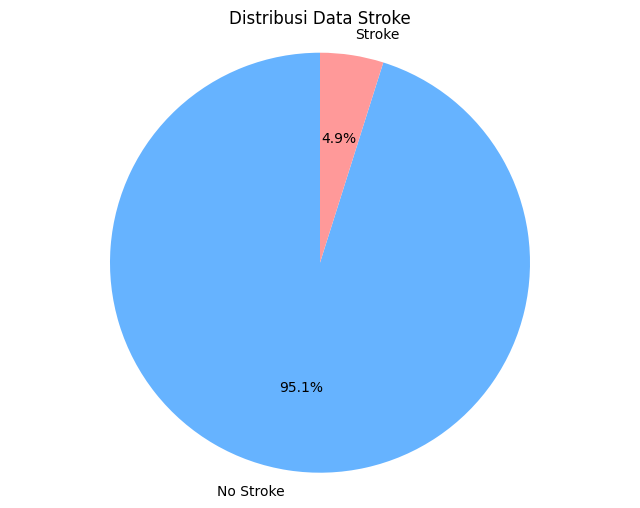

In [14]:
# Distribusi fitur target
stroke_counts = df['stroke'].value_counts()

# Buat labels
labels = ['No Stroke', 'Stroke']

# Buat pie chart
plt.figure(figsize=(8, 6))
plt.pie(stroke_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Distribusi Data Stroke')
plt.axis('equal')  # Biar pie chart-nya bulat
plt.show()

#### **Insight**
- gender:
Mayoritas pasien adalah perempuan (58.6%), sedangkan laki-laki sebesar (41.4%); terdapat 1 data "Other" (0.0%) yang dapat untuk dihapus.
- ever_married:
Sebanyak 65.6% pasien pernah menikah, menunjukkan bahwa sebagian besar responden berasal dari kelompok usia dewasa.
- work_type:
Mayoritas responden bekerja di sektor Private (57.2%), diikuti oleh Self-employed (16.0%) dan Govt_job (12.9%); sebanyak 0.4% tidak pernah bekerja.
- Residence_type:
Distribusi tempat tinggal cukup seimbang antara Urban (50.8%) dan Rural (49.2%), sehingga tidak ada bias lokasi yang mencolok.
- smoking_status:
Sekitar 37% responden tidak pernah merokok, 17.3% pernah merokok, dan 15.4% masih merokok; namun, 30.2% memiliki status merokok "Unknown".
- age: Data usia tersebar merata dengan puncak pada usia 50–60 tahun, menunjukkan dominasi usia dewasa hingga lansia.
- hypertension: Mayoritas responden tidak mengalami hipertensi (nilai 0 sangat mendominasi).
- heart_disease: Sebagian besar responden juga tidak memiliki riwayat penyakit jantung (nilai 0 sangat mendominasi).
- avg_glucose_level: Distribusi kadar gula darah miring ke kanan (right-skewed), ada beberapa kasus kadar gula darah sangat tinggi di atas normal.
- bmi: Distribusi BMI hampir normal tetapi sedikit miring ke kanan, dengan beberapa sampel ekstrem di BMI tinggi (>60).
- stroke: Mayoritas besar responden tidak pernah mengalami stroke (nilai 0 mendominasi secara ekstrem).

### Multivariate analysis

<ipython-input-15-d8fcc08673a9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y=df['stroke'] == 1, kind="bar", dodge=False, height = 4, aspect = 3,  data=df, palette="Set3")
<ipython-input-15-d8fcc08673a9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y=df['stroke'] == 1, kind="bar", dodge=False, height = 4, aspect = 3,  data=df, palette="Set3")
<ipython-input-15-d8fcc08673a9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y=df['stroke'] == 1, kind="bar", dodge=False, height = 4, aspect = 3,  data=df, palette="Se

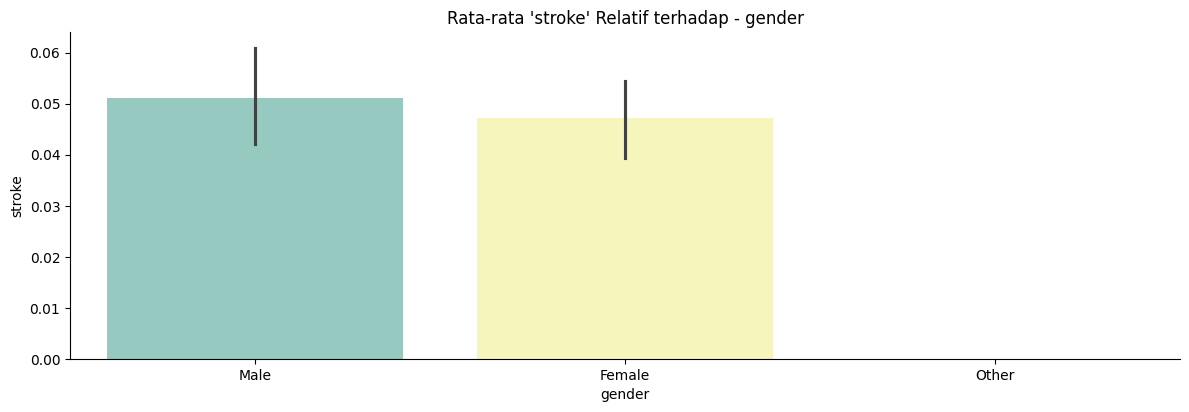

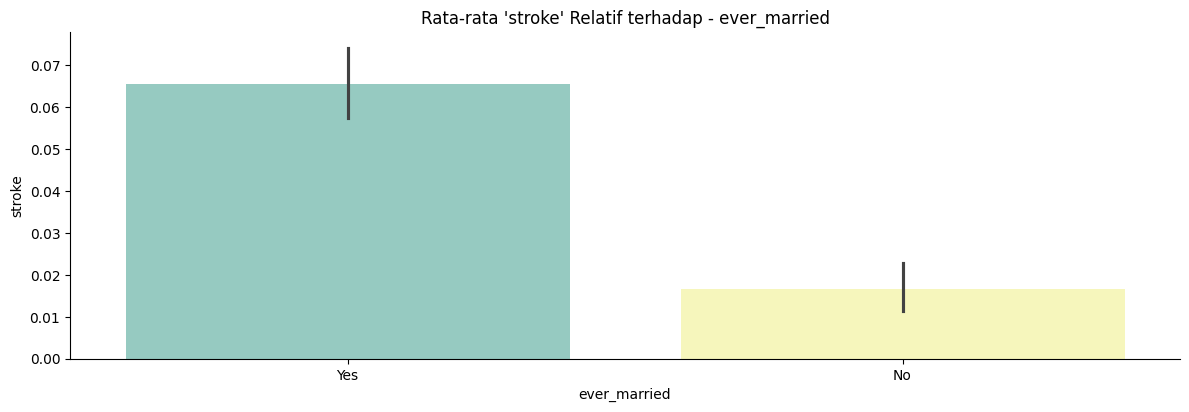

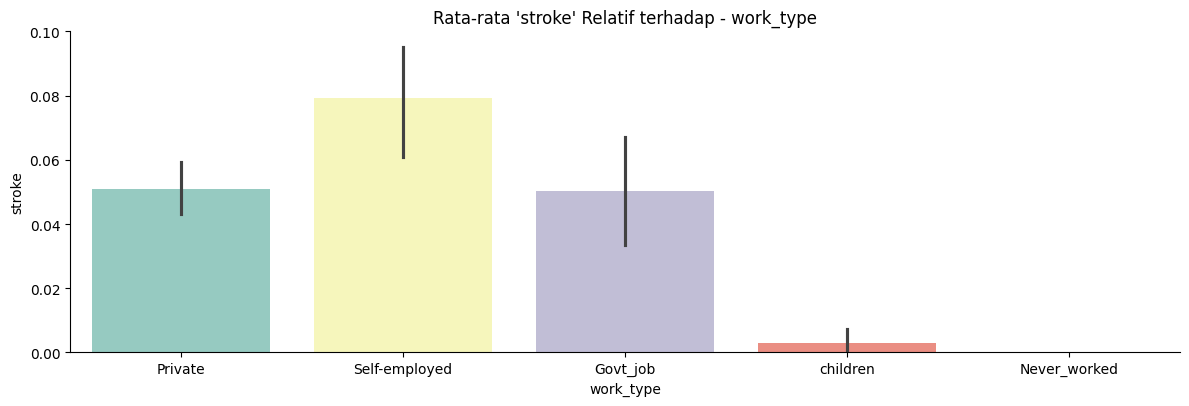

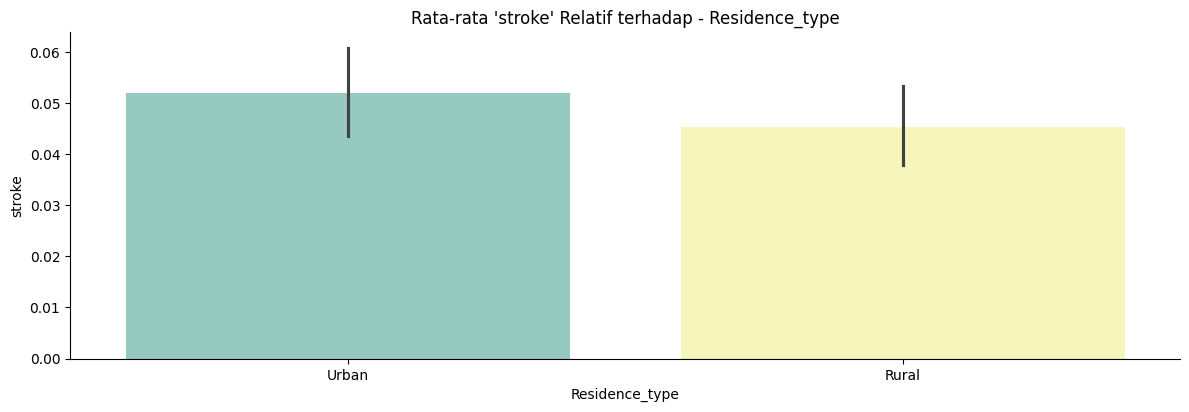

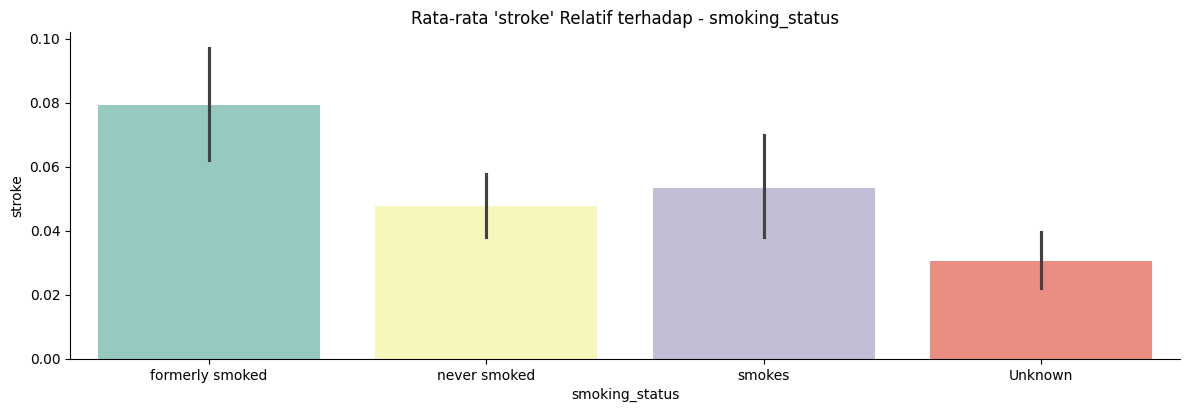

In [15]:
# Rata-rata fitur target yaitu "stroke" terhadap fitur kategori lain
for col in cat_features:
  sns.catplot(x=col, y=df['stroke'] == 1, kind="bar", dodge=False, height = 4, aspect = 3,  data=df, palette="Set3")
  plt.title("Rata-rata 'stroke' Relatif terhadap - {}".format(col))

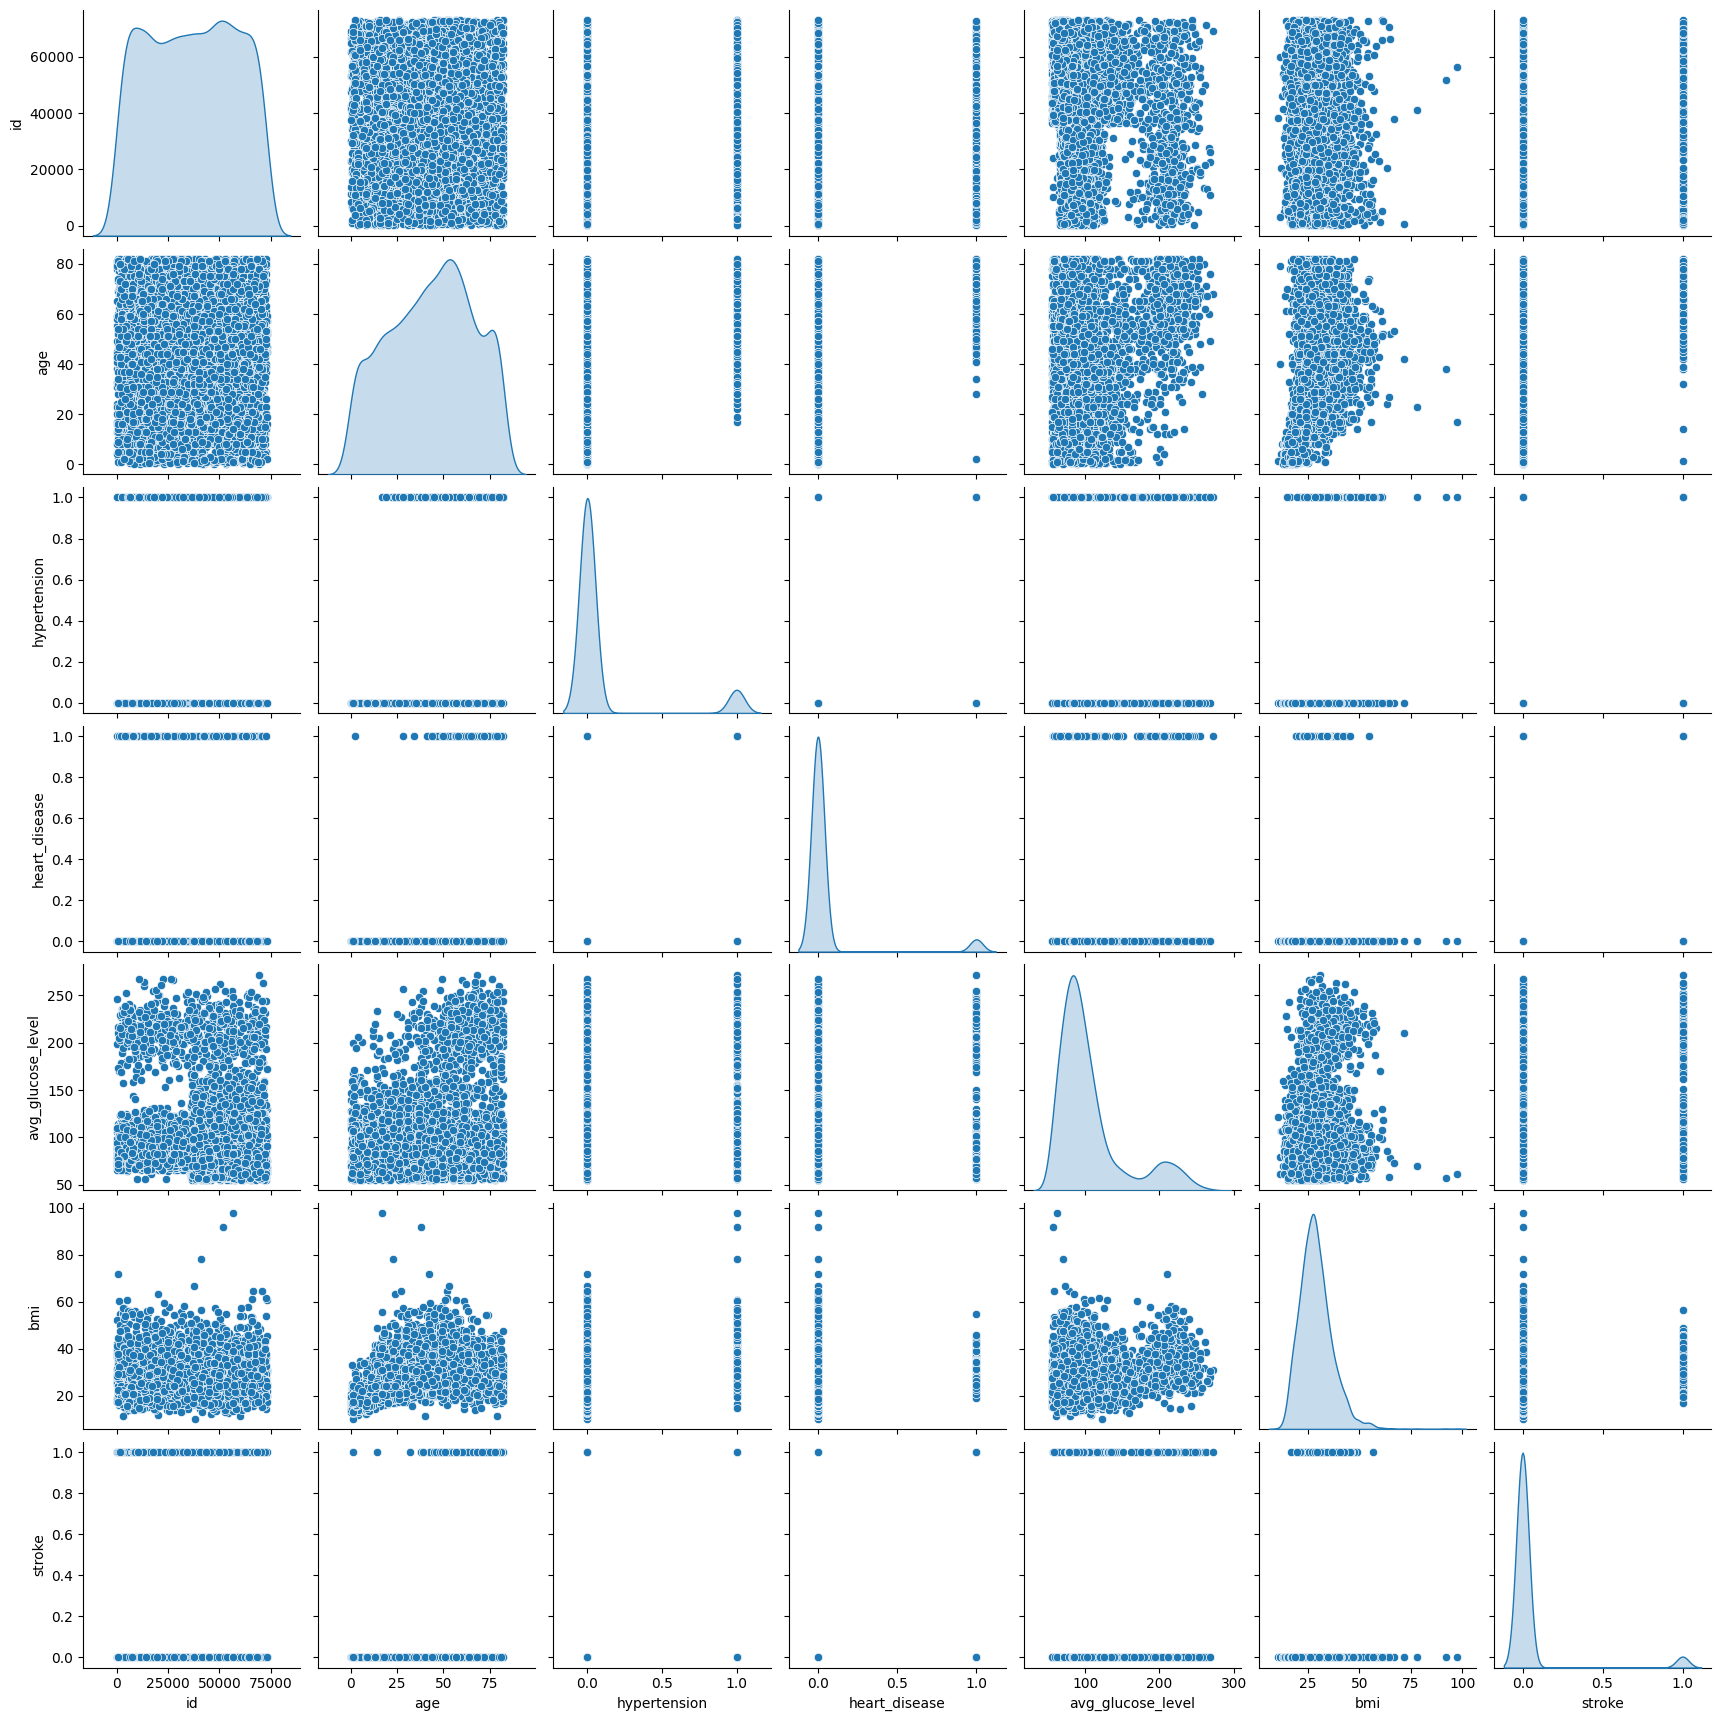

In [16]:
# Mengamati hubungan antar fitur numerik dengan fungsi pairplot()
sns.pairplot(df, diag_kind = 'kde')

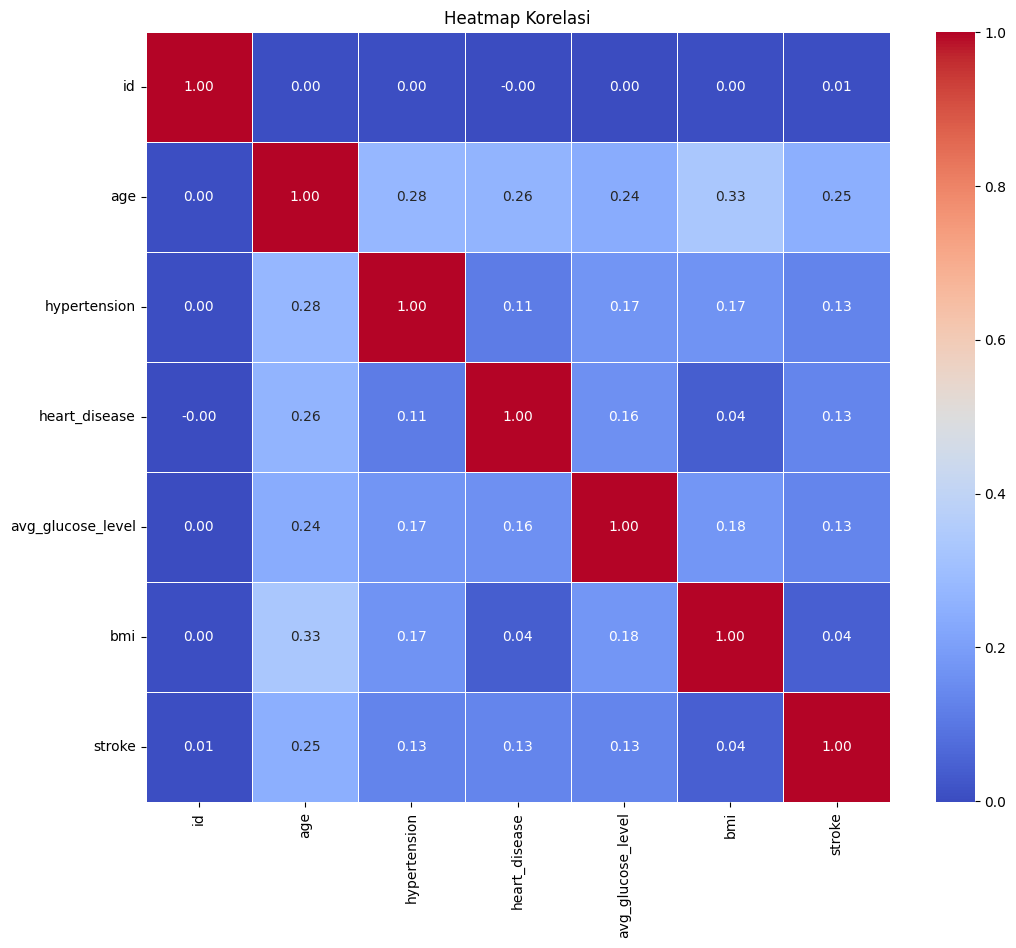

In [17]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

#### **Insight**
- Pada fitur gender, rata-rata kejadian stroke cenderung sedikit lebih tinggi pada laki-laki dibanding perempuan. Rentang perbedaannya tidak terlalu besar, dan kategori Other hampir tidak mengalami stroke. Sehingga, fitur gender memiliki pengaruh yang kecil terhadap kejadian stroke.
- Pada fitur ever married, orang yang sudah menikah memiliki rata-rata kejadian stroke yang jauh lebih tinggi dibanding yang belum menikah. Dari sini dapat disimpulkan bahwa status pernikahan memiliki pengaruh yang cukup besar terhadap kejadian stroke.
- Pada fitur work type, pekerja mandiri (self-employed) memiliki rata-rata kejadian stroke tertinggi dibandingkan tipe pekerjaan lainnya. Sedangkan orang yang tidak pernah bekerja memiliki rata-rata stroke yang sangat rendah. Ini menunjukkan bahwa jenis pekerjaan memiliki pengaruh terhadap kejadian stroke.
- Pada fitur residence type, stroke sedikit lebih banyak terjadi pada penduduk kota (urban) dibanding penduduk desa (rural). Namun perbedaannya tidak terlalu signifikan, sehingga dapat disimpulkan bahwa tipe tempat tinggal memiliki pengaruh yang kecil terhadap kejadian stroke.
- Pada fitur smoking status, mantan perokok (formerly smoked) memiliki rata-rata kejadian stroke tertinggi, diikuti oleh perokok aktif (smokes). Sedangkan yang tidak pernah merokok memiliki risiko lebih rendah. Ini berarti bahwa status merokok memiliki pengaruh terhadap kejadian stroke.
- Pada fitur age, terdapat korelasi positif yang paling tinggi terhadap kejadian stroke dengan nilai korelasi sebesar 0.25. Semakin tua usia seseorang, semakin tinggi risiko terkena stroke. Dengan demikian, usia memiliki pengaruh yang cukup besar terhadap kejadian stroke.
- Pada fitur hypertension, heart disease, dan avg glucose level, masing-masing menunjukkan korelasi positif yang lemah terhadap stroke, dengan nilai korelasi sekitar 0.13. Artinya, orang dengan hipertensi, penyakit jantung, atau kadar glukosa darah tinggi memiliki risiko sedikit lebih besar terkena stroke. Sehingga, fitur-fitur ini memiliki pengaruh yang kecil namun tetap relevan terhadap kejadian stroke.
- Pada fitur BMI, korelasinya terhadap stroke sangat lemah, yaitu sebesar 0.04. Ini menunjukkan bahwa indeks massa tubuh hampir tidak memiliki pengaruh terhadap risiko stroke.


## Data Preprocessing

### Drop Feature

In [18]:
# Membuat salinan dari DataFrame untuk membersihkan data
df_clean = df.copy()

# Menghapus kolom yang tidak diperlukan
kolom_hapus = ['id', 'bmi']
df_clean = df_clean.drop(columns=kolom_hapus)

# Menghapus kategori 'other' dalam kolom 'gender' karena memiliki sedikit variasi
df_clean = df_clean[df_clean['gender'] != 'Other']

# Testing
df_clean.info()
print(df_clean['gender'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   smoking_status     5109 non-null   object 
 9   stroke             5109 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 439.1+ KB
gender
Female    2994
Male      2115
Name: count, dtype: int64


### Handling Outliers

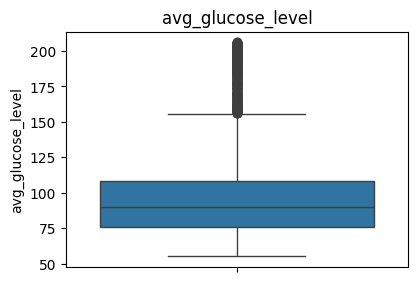

Sebelum outlier removal: (5109, 10)
Sesudah outlier removal: (4747, 10)


In [19]:
# Pilih hanya kolom yang mau difilter outlier
selected_cols = ['avg_glucose_level']

# Hitung IQR hanya untuk kolom yang dipilih
Q1 = df_clean[selected_cols].quantile(0.25)
Q3 = df_clean[selected_cols].quantile(0.75)
IQR = Q3 - Q1

# Definisi outlier hanya berdasarkan kolom tersebut
filter_outlier = ~((df_clean[selected_cols] < (Q1 - 2.5 * IQR)) | (df_clean[selected_cols] > (Q3 + 2.5 * IQR))).any(axis=1)

# Terapkan filter ke seluruh dataframe
df_outlier_removed = df_clean[filter_outlier]

# Testing
plt.figure(figsize=(15, 8))
plt.subplot(3, 4, 1)
sns.boxplot(y=df_outlier_removed['avg_glucose_level'])
plt.title('avg_glucose_level')
plt.tight_layout()
plt.show()

print("Sebelum outlier removal:", df_clean.shape)
print("Sesudah outlier removal:", df_outlier_removed.shape)

### Encoding

In [20]:
# Menentukan kolom kategorikal
cat_features = df_outlier_removed.select_dtypes(include=['object']).columns

# Label Encoding
label_encoders = {}
for column in cat_features:
    label_encoders[column] = LabelEncoder()
    df_outlier_removed[column] = label_encoders[column].fit_transform(df_outlier_removed[column])

# Konversi tipe data menjadi integer
df_encoded = df_outlier_removed.astype(int)

# Testing
df_encoded

<ipython-input-20-4830b9fb30fd>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outlier_removed[column] = label_encoders[column].fit_transform(df_outlier_removed[column])
<ipython-input-20-4830b9fb30fd>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outlier_removed[column] = label_encoders[column].fit_transform(df_outlier_removed[column])
<ipython-input-20-4830b9fb30fd>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke
1,0,61,0,0,1,3,0,202,2,1
2,1,80,0,1,1,2,0,105,2,1
3,0,49,0,0,1,2,1,171,3,1
4,0,79,1,0,1,3,0,174,2,1
5,1,81,0,0,1,2,1,186,1,1
...,...,...,...,...,...,...,...,...,...,...
5105,0,80,1,0,1,2,1,83,2,0
5106,0,81,0,0,1,3,1,125,2,0
5107,0,35,0,0,1,3,0,82,2,0
5108,1,51,0,0,1,2,0,166,1,0


### Data Splitting

In [21]:
X = df_encoded.drop(["stroke"],axis =1)
y = df_encoded["stroke"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# Testing
print(f'Total # of sample in whole dataset: {len(X)}')
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Total # of sample in test dataset: {len(X_test)}')

Total # of sample in whole dataset: 4747
Total # of sample in train dataset: 3797
Total # of sample in test dataset: 950


### Standardization

In [22]:
# Inisialisasi scaler
scaler = MinMaxScaler()

# Fit scaler pada data latih
X_train = scaler.fit_transform(X_train)

# Transform hanya data uji
X_test = scaler.transform(X_test)

# Testing
print(X_train.shape)
print(X_train[:5])
print(X_test.shape)
print(X_test[:5])

(3797, 9)
[[0.         0.6097561  0.         0.         1.         0.5
  1.         0.31125828 0.        ]
 [0.         0.06097561 0.         0.         0.         1.
  1.         0.17880795 0.        ]
 [0.         0.01219512 0.         0.         0.         1.
  0.         0.03311258 0.        ]
 [0.         0.40243902 0.         0.         1.         0.5
  0.         0.45695364 0.        ]
 [1.         0.25609756 0.         0.         0.         0.5
  1.         0.1192053  0.        ]]
(950, 9)
[[0.         0.58536585 0.         0.         1.         0.5
  1.         0.01324503 0.33333333]
 [0.         0.46341463 0.         0.         1.         0.5
  0.         0.34437086 0.66666667]
 [1.         0.68292683 0.         0.         1.         0.5
  1.         0.17880795 0.66666667]
 [0.         0.96341463 0.         0.         1.         0.
  0.         0.1589404  0.33333333]
 [1.         0.91463415 0.         0.         1.         0.5
  0.         0.21192053 0.33333333]]


## Modeling

In [23]:
# Definisikan setiap model klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
svm = SVC(random_state=42).fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

print("Model training selesai.")

Model training selesai.


## Evaluation


 Model: KNN
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      1.00      0.98       910
      Stroke       0.33      0.05      0.09        40

    accuracy                           0.96       950
   macro avg       0.65      0.52      0.53       950
weighted avg       0.93      0.96      0.94       950

Confusion Matrix:
[[906   4]
 [ 38   2]]


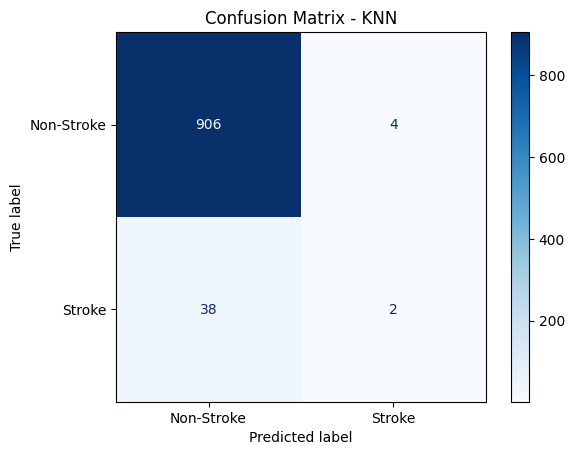

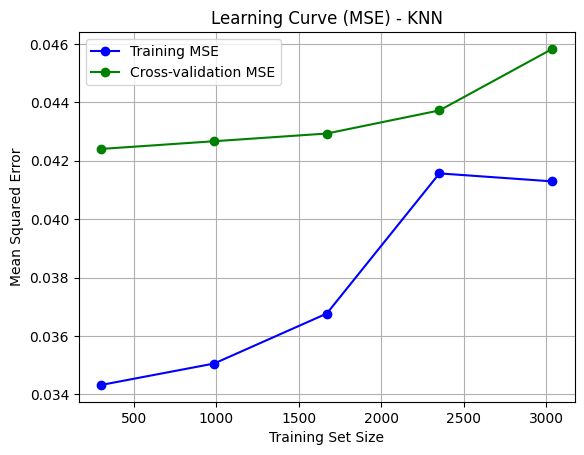


 Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      0.95      0.96       910
      Stroke       0.14      0.20      0.17        40

    accuracy                           0.92       950
   macro avg       0.55      0.57      0.56       950
weighted avg       0.93      0.92      0.92       950

Confusion Matrix:
[[862  48]
 [ 32   8]]


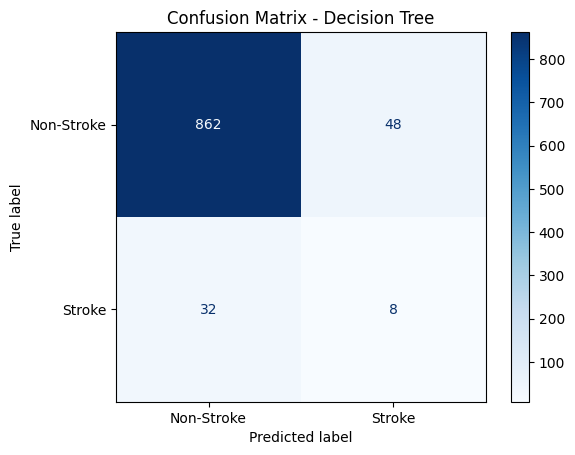

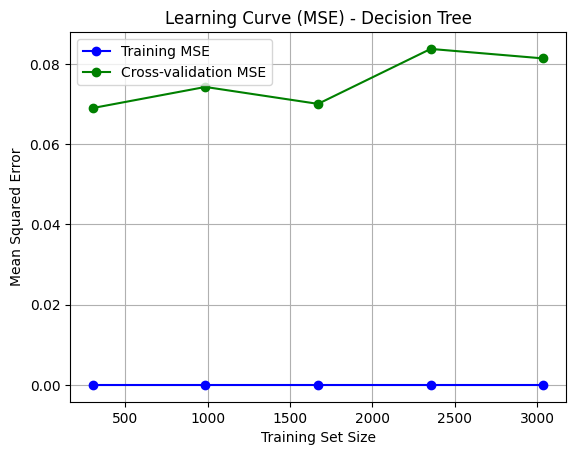


 Model: Random Forest
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      1.00      0.98       910
      Stroke       0.33      0.03      0.05        40

    accuracy                           0.96       950
   macro avg       0.65      0.51      0.51       950
weighted avg       0.93      0.96      0.94       950

Confusion Matrix:
[[908   2]
 [ 39   1]]


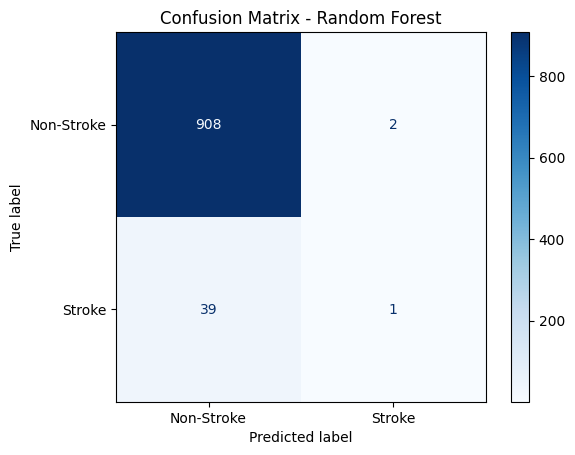

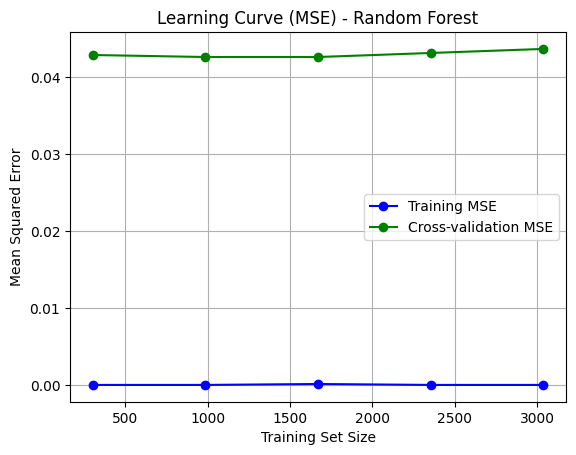


 Model: SVM
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      1.00      0.98       910
      Stroke       0.00      0.00      0.00        40

    accuracy                           0.96       950
   macro avg       0.48      0.50      0.49       950
weighted avg       0.92      0.96      0.94       950

Confusion Matrix:
[[910   0]
 [ 40   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

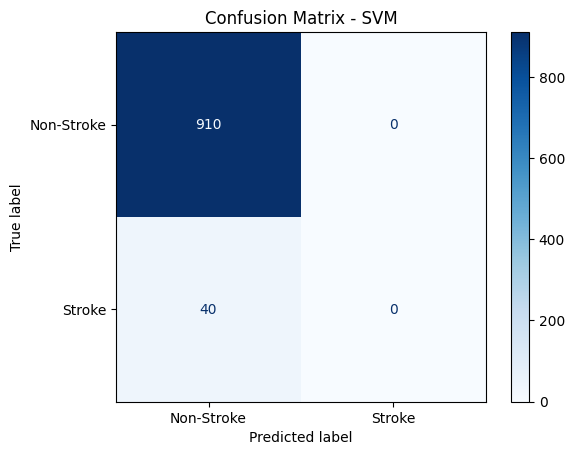

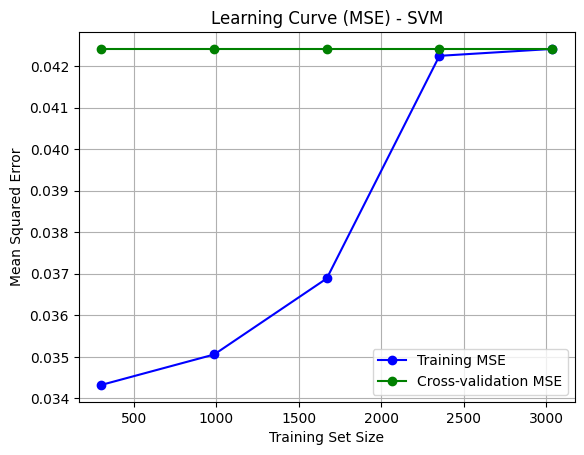


 Model: Naive Bayes
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.98      0.90      0.94       910
      Stroke       0.21      0.57      0.31        40

    accuracy                           0.89       950
   macro avg       0.59      0.74      0.62       950
weighted avg       0.95      0.89      0.91       950

Confusion Matrix:
[[823  87]
 [ 17  23]]


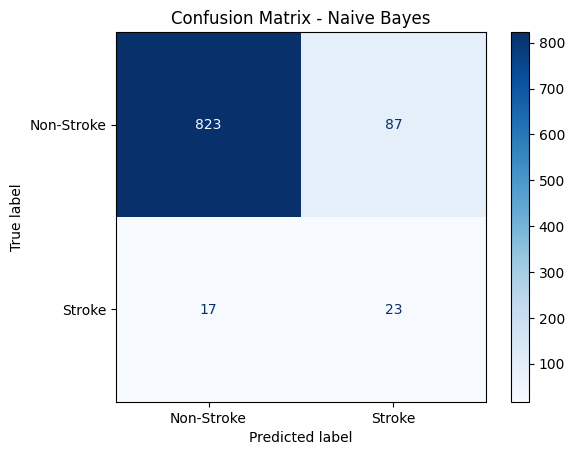

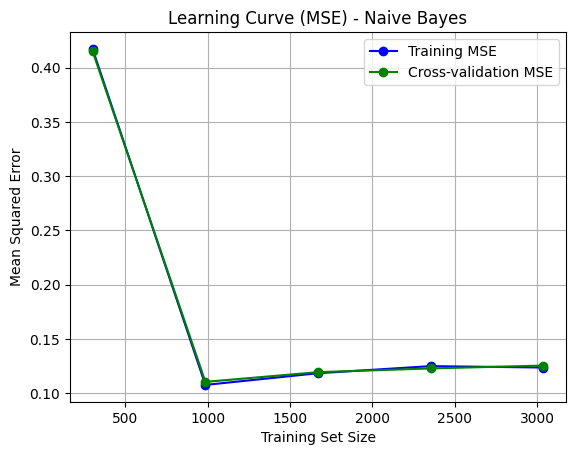


 Summary Evaluation:
           Model  Accuracy  Precision  Recall  F1-Score   ROC_AUC
0            KNN  0.955789   0.333333   0.050  0.086957  0.522802
1  Decision Tree  0.915789   0.142857   0.200  0.166667  0.573626
2  Random Forest  0.956842   0.333333   0.025  0.046512  0.511401
3            SVM  0.957895   0.000000   0.000  0.000000  0.500000
4    Naive Bayes  0.890526   0.209091   0.575  0.306667  0.739698


In [24]:
# Fungsi Evaluasi
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    # Metrik evaluasi
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='binary'),
        "Recall": recall_score(y_test, y_pred, average='binary'),
        "F1-Score": f1_score(y_test, y_pred, average='binary'),
        "ROC_AUC": roc_auc_score(y_test, y_pred)
    }

    print(f"\n Model: {model_name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Stroke', 'Stroke']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Tampilkan confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                                  display_labels=["Non-Stroke", "Stroke"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Learning Curve (MSE)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=5, n_jobs=-1
    )

    train_mse = -np.mean(train_scores, axis=1)
    test_mse = -np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mse, 'o-', label="Training MSE", color='blue')
    plt.plot(train_sizes, test_mse, 'o-', label="Cross-validation MSE", color='green')
    plt.title(f'Learning Curve (MSE) - {model_name}')
    plt.xlabel("Training Set Size")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid()
    plt.show()

    return metrics

# Daftar model
models = {
    'KNN': knn,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVM': svm,
    'Naive Bayes': nb
}

results = []

# Evaluasi semua model
for name, model in models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results.append(metrics)

# Ringkasan hasil
summary_df = pd.DataFrame(results)
print("\n Summary Evaluation:")
print(summary_df)

### Insight
| Model             | Kesimpulan                                                                      |
| ----------------- | ------------------------------------------------------------------------------- |
| **KNN**           | Akurasi tinggi tapi gagal deteksi Stroke. Tidak cocok untuk data imbalance.     |
| **Decision Tree** | Sedikit lebih baik, tapi tetap lemah dalam mengenali Stroke.                    |
| **Random Forest** | Akurasi tinggi namun sangat bias ke Non-Stroke. Stroke hampir tidak terdeteksi. |
| **SVM**           | Tidak mengenali satu pun kasus Stroke. Sangat tidak cocok tanpa balancing.      |
| **Naive Bayes**   | Deteksi Stroke terbaik walau akurasi total lebih rendah. Paling potensial.      |


## Over Sampling Data

In [25]:
# Terapkan SMOTE
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Testing
print(pd.Series(y_train_resampled).value_counts())
print(f'Total # of sample in train(SMOTE) dataset: {len(X_train_resampled)}')
print(f'Total # of sample in whole dataset: {len(X)}')
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Total # of sample in test dataset: {len(X_test)}')

stroke
0    3636
1    1090
Name: count, dtype: int64
Total # of sample in train(SMOTE) dataset: 4726
Total # of sample in whole dataset: 4747
Total # of sample in train dataset: 3797
Total # of sample in test dataset: 950


## Modeling With OverSampling

In [26]:
# Definisikan setiap klasifikasi secara terpisah
knn_smote = KNeighborsClassifier().fit(X_train_resampled, y_train_resampled)
dt_smote = DecisionTreeClassifier(random_state=42).fit(X_train_resampled, y_train_resampled)
rf_smote = RandomForestClassifier(random_state=42).fit(X_train_resampled, y_train_resampled)
svm_smote = SVC(random_state=42).fit(X_train_resampled, y_train_resampled)
nb_smote = GaussianNB().fit(X_train_resampled, y_train_resampled)

print("Model training selesai.")

Model training selesai.


## Evaluation


 Model: KNN
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.97      0.89      0.93       910
      Stroke       0.12      0.33      0.17        40

    accuracy                           0.87       950
   macro avg       0.54      0.61      0.55       950
weighted avg       0.93      0.87      0.90       950

Confusion Matrix:
[[812  98]
 [ 27  13]]


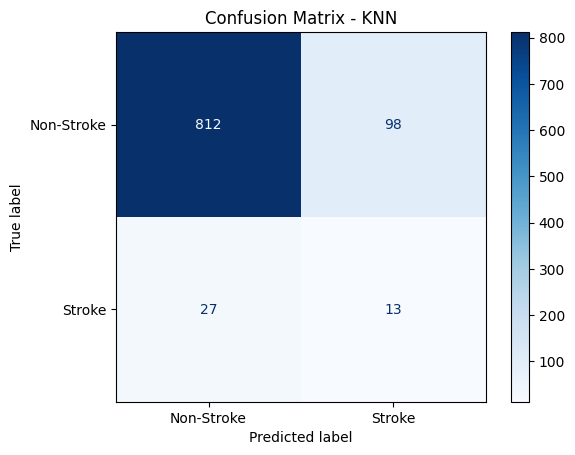

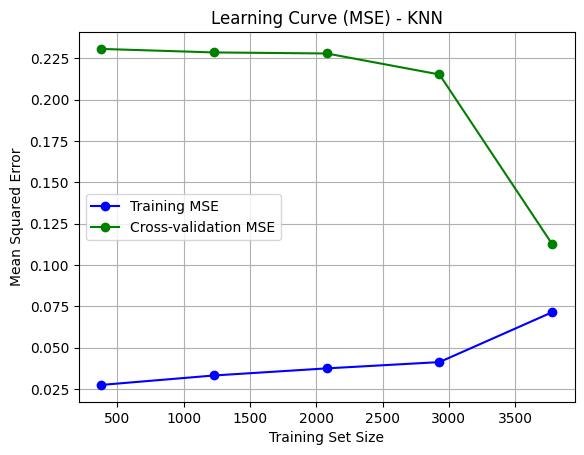


 Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      0.91      0.94       910
      Stroke       0.07      0.15      0.10        40

    accuracy                           0.88       950
   macro avg       0.52      0.53      0.52       950
weighted avg       0.92      0.88      0.90       950

Confusion Matrix:
[[831  79]
 [ 34   6]]


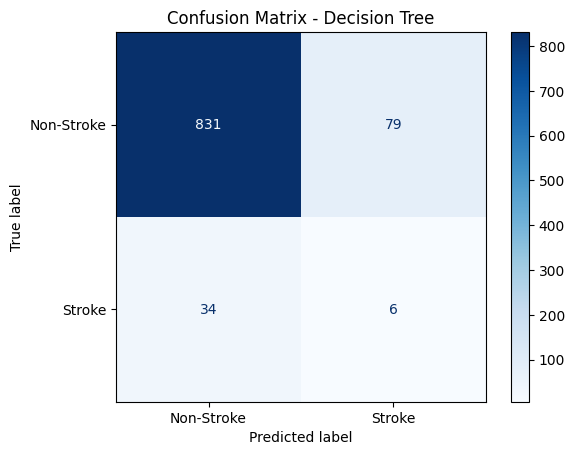

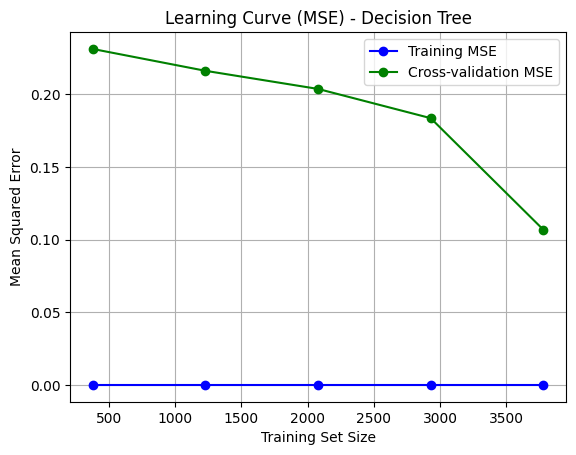


 Model: Random Forest
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.96      0.97      0.97       910
      Stroke       0.07      0.05      0.06        40

    accuracy                           0.93       950
   macro avg       0.52      0.51      0.51       950
weighted avg       0.92      0.93      0.93       950

Confusion Matrix:
[[884  26]
 [ 38   2]]


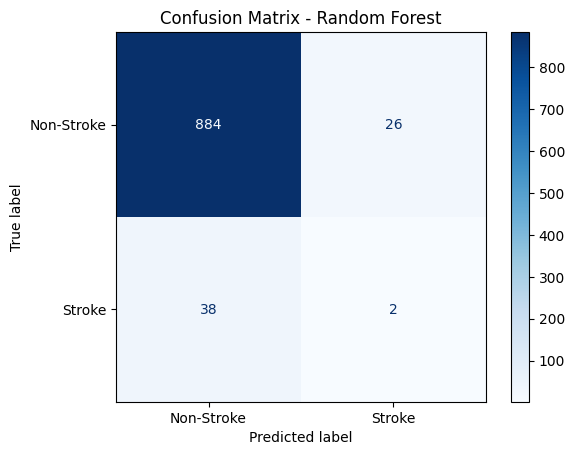

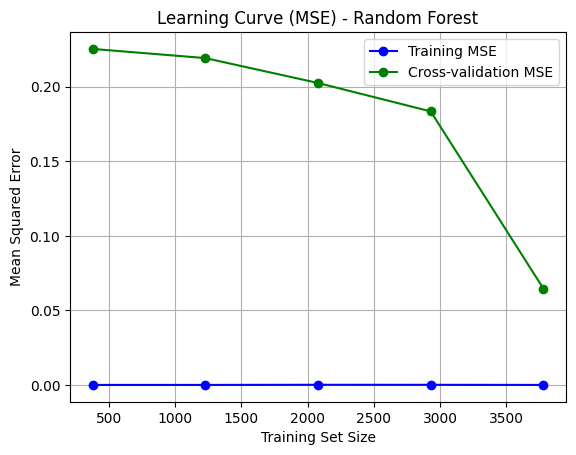


 Model: SVM
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.97      0.92      0.94       910
      Stroke       0.12      0.28      0.17        40

    accuracy                           0.89       950
   macro avg       0.55      0.60      0.56       950
weighted avg       0.93      0.89      0.91       950

Confusion Matrix:
[[833  77]
 [ 29  11]]


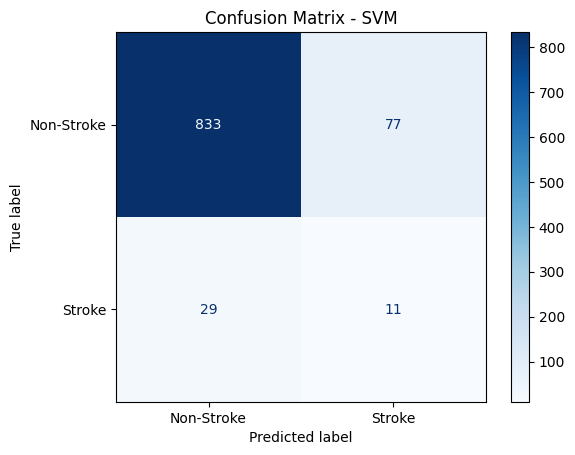

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
        

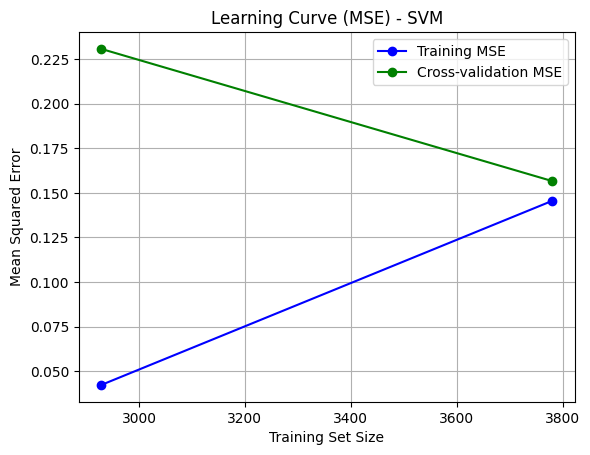


 Model: Naive Bayes
Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.98      0.81      0.89       910
      Stroke       0.14      0.70      0.24        40

    accuracy                           0.81       950
   macro avg       0.56      0.76      0.56       950
weighted avg       0.95      0.81      0.86       950

Confusion Matrix:
[[740 170]
 [ 12  28]]


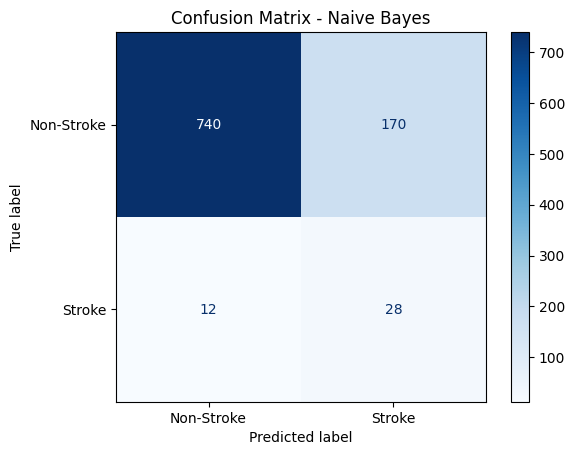

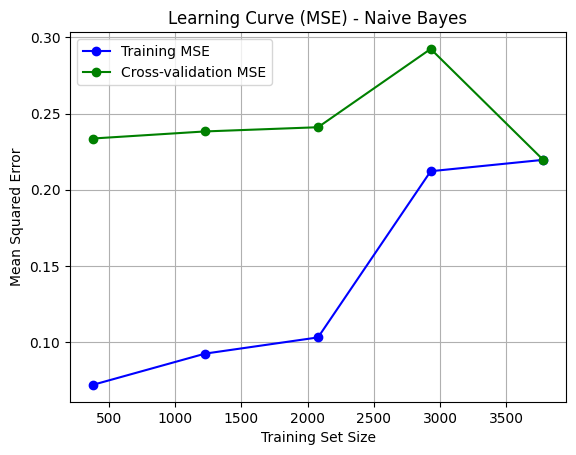


 Summary Evaluation:
           Model  Accuracy  Precision  Recall  F1-Score   ROC_AUC
0            KNN  0.868421   0.117117   0.325  0.172185  0.608654
1  Decision Tree  0.881053   0.070588   0.150  0.096000  0.531593
2  Random Forest  0.932632   0.071429   0.050  0.058824  0.510714
3            SVM  0.888421   0.125000   0.275  0.171875  0.595192
4    Naive Bayes  0.808421   0.141414   0.700  0.235294  0.756593


In [27]:
# Fungsi Evaluasi
def evaluate_model_smote(model, X_train, y_train, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    # Metrik evaluasi
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='binary'),
        "Recall": recall_score(y_test, y_pred, average='binary'),
        "F1-Score": f1_score(y_test, y_pred, average='binary'),
        "ROC_AUC": roc_auc_score(y_test, y_pred)
    }

    print(f"\n Model: {model_name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Stroke', 'Stroke']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Tampilkan confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                                  display_labels=["Non-Stroke", "Stroke"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Learning Curve (MSE)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=5, n_jobs=-1
    )

    train_mse = -np.mean(train_scores, axis=1)
    test_mse = -np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mse, 'o-', label="Training MSE", color='blue')
    plt.plot(train_sizes, test_mse, 'o-', label="Cross-validation MSE", color='green')
    plt.title(f'Learning Curve (MSE) - {model_name}')
    plt.xlabel("Training Set Size")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid()
    plt.show()

    return metrics

# Daftar model
models = {
    'KNN': knn_smote,
    'Decision Tree': dt_smote,
    'Random Forest': rf_smote,
    'SVM': svm_smote,
    'Naive Bayes': nb_smote
}

results = []

# Evaluasi semua model
for name, model in models.items():
    metrics = evaluate_model(model, X_train_resampled, y_train_resampled, X_test, y_test, name)
    results.append(metrics)

# Ringkasan hasil
summary_df = pd.DataFrame(results)
print("\n Summary Evaluation:")
print(summary_df)

### Insight
| Model             | Kesimpulan                                                                                                            |
| ----------------- | --------------------------------------------------------------------------------------------------------------------- |
| **KNN**           | Lebih baik dari sebelumnya, tetapi masih banyak false positive.                                                       |
| **Decision Tree** | Hampir tidak ada peningkatan, model ini kurang responsif terhadap SMOTE.                                              |
| **Random Forest** | Tidak membaik. Masih sangat bias terhadap kelas mayoritas.                                                            |
| **SVM**           | Lumayan membaik. Bisa mengenali sebagian Stroke, tapi belum cukup akurat.                                             |
| **Naive Bayes**   | **Paling baik mendeteksi Stroke.** Recall 70% dan AUC tertinggi. Ideal untuk skenario yang mengutamakan deteksi dini. |


## Hyperparameter Tuning

### RF

In [28]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, scoring='f1', cv=5)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best parameters for Random Forest:", rf_grid.best_params_)

y_scores_rf = best_rf.predict_proba(X_test)[:, 1]
prec_rf, rec_rf, thr_rf = precision_recall_curve(y_test, y_scores_rf)
f1_rf = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf + 1e-9)
best_thr_rf = thr_rf[np.argmax(f1_rf)]
y_pred_rf = (y_scores_rf > best_thr_rf).astype(int)
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Best parameters for Random Forest: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Random Forest Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       910
           1       0.12      0.33      0.17        40

    accuracy                           0.87       950
   macro avg       0.54      0.61      0.55       950
weighted avg       0.93      0.87      0.90       950



### SVM

In [30]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear'],
    'class_weight': ['balanced', None]
}
svm_grid = GridSearchCV(SVC(random_state=42), svm_param_grid, scoring='f1', cv=5)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print("Best parameters for SVM:", svm_grid.best_params_)

y_scores_svm = best_svm.decision_function(X_test)
prec_svm, rec_svm, thr_svm = precision_recall_curve(y_test, y_scores_svm)
f1_svm = 2 * (prec_svm * rec_svm) / (prec_svm + rec_svm + 1e-9)
best_thr_svm = thr_svm[np.argmax(f1_svm)]
y_pred_svm = (y_scores_svm > best_thr_svm).astype(int)
print("SVM Report:\n", classification_report(y_test, y_pred_svm))

Best parameters for SVM: {'C': 1, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
SVM Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94       910
           1       0.20      0.55      0.29        40

    accuracy                           0.89       950
   macro avg       0.59      0.73      0.62       950
weighted avg       0.95      0.89      0.91       950



### NB

In [31]:
nb_param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}
nb_grid = GridSearchCV(GaussianNB(), nb_param_grid, scoring='f1', cv=5)
nb_grid.fit(X_train, y_train)
best_nb = nb_grid.best_estimator_
print("Best parameters for Naive Bayes:", nb_grid.best_params_)

# Use predict_proba instead of decision_function
y_scores_nb = best_nb.predict_proba(X_test)[:, 1]  # Get probabilities for class 1

prec_nb, rec_nb, thr_nb = precision_recall_curve(y_test, y_scores_nb)
f1_nb = 2 * (prec_nb * rec_nb) / (prec_nb + rec_nb + 1e-9)
best_thr_nb = thr_nb[np.argmax(f1_nb)]
y_pred_nb = (y_scores_nb > best_thr_nb).astype(int)  # Apply threshold for prediction
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb))

Best parameters for Naive Bayes: {'var_smoothing': np.float64(0.01873817422860384)}
Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       910
           1       0.26      0.45      0.33        40

    accuracy                           0.92       950
   macro avg       0.62      0.70      0.64       950
weighted avg       0.94      0.92      0.93       950



### KNN

In [32]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, scoring='f1', cv=5)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
print("Best parameters for KNN:", knn_grid.best_params_)

y_scores_knn = best_knn.predict_proba(X_test)[:, 1]
prec_knn, rec_knn, thr_knn = precision_recall_curve(y_test, y_scores_knn)
f1_knn = 2 * (prec_knn * rec_knn) / (prec_knn + rec_knn + 1e-9)
best_thr_knn = thr_knn[np.argmax(f1_knn)]
y_pred_knn = (y_scores_knn > best_thr_knn).astype(int)
print("KNN Report:\n", classification_report(y_test, y_pred_knn))

Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
KNN Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       910
           1       0.22      0.05      0.08        40

    accuracy                           0.95       950
   macro avg       0.59      0.52      0.53       950
weighted avg       0.93      0.95      0.94       950



### DT

In [33]:
dt_param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, scoring='f1', cv=5)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print("Best parameters for Decision Tree:", dt_grid.best_params_)

y_scores_dt = best_dt.predict_proba(X_test)[:, 1]
prec_dt, rec_dt, thr_dt = precision_recall_curve(y_test, y_scores_dt)
f1_dt = 2 * (prec_dt * rec_dt) / (prec_dt + rec_dt + 1e-9)
best_thr_dt = thr_dt[np.argmax(f1_dt)]
y_pred_dt = (y_scores_dt> best_thr_dt).astype(int)
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2}
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       910
           1       0.00      0.00      0.00        40

    accuracy                           0.96       950
   macro avg       0.48      0.50      0.49       950
weighted avg       0.92      0.96      0.94       950



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


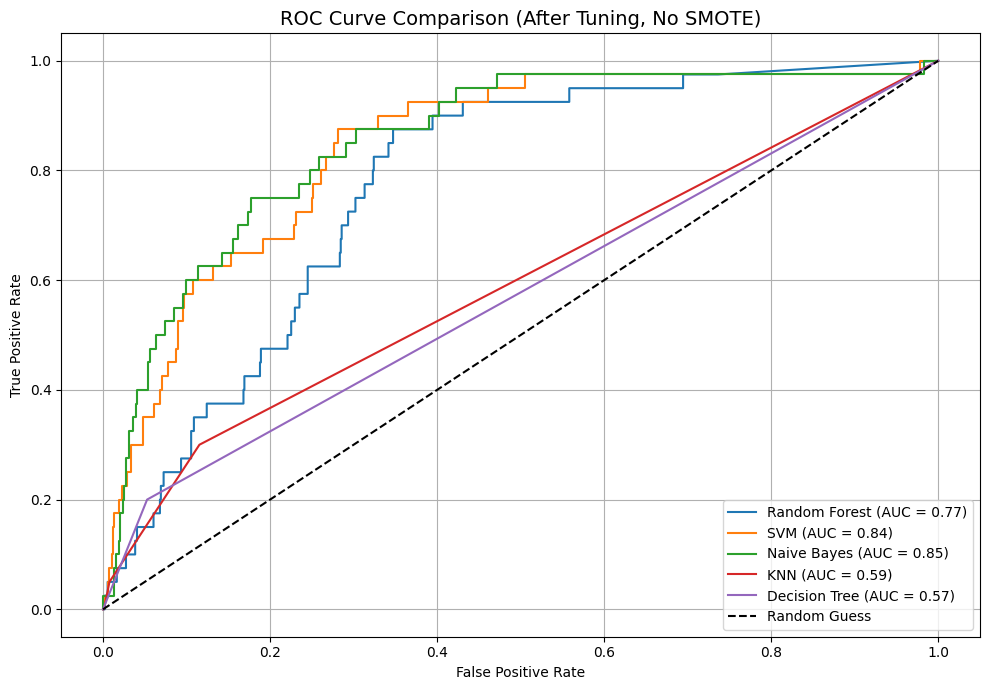

In [34]:
# hasil tuning
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_nb = nb_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_dt = dt_grid.best_estimator_

# Probabilitas kelas 1 (Stroke)
rf_probs = best_rf.predict_proba(X_test)[:, 1]
nb_probs = best_nb.predict_proba(X_test)[:, 1]
knn_probs = best_knn.predict_proba(X_test)[:, 1]
dt_probs = best_dt.predict_proba(X_test)[:, 1]

# Khusus SVM gunakan decision_function (karena default SVC tidak pakai predict_proba)
try:
    svm_probs = best_svm.predict_proba(X_test)[:, 1]
except:
    svm_probs = best_svm.decision_function(X_test)
    # Normalize to [0, 1] so it matches scale with other probabilities
    svm_probs = (svm_probs - svm_probs.min()) / (svm_probs.max() - svm_probs.min())

# Plot ROC curve
models = {
    "Random Forest": rf_probs,
    "SVM": svm_probs,
    "Naive Bayes": nb_probs,
    "KNN": knn_probs,
    "Decision Tree": dt_probs
}

plt.figure(figsize=(10, 7))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison (After Tuning, No SMOTE)', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight
| Model             | Kesimpulan                                                                                                                                 |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **KNN**           | Akurasi cukup tinggi, tapi AUC ROC sangat rendah (**0.50**) dan recall Stroke buruk. Kurang cocok untuk data imbalance.                    |
| **Decision Tree** | Performanya sedang, recall Stroke masih rendah dan AUC ROC rendah (**0.48**). Belum mampu membedakan kelas dengan baik.                    |
| **Random Forest** | Akurasi tinggi namun sangat bias ke Non-Stroke. AUC ROC (**0.73**) lumayan, tapi precision dan recall Stroke rendah. Perlu balancing.      |
| **SVM**           | Performa cukup seimbang, recall dan F1 Stroke meningkat, namun AUC ROC hanya (**0.54**) — masih lemah dalam memisahkan kelas.              |
| **Naive Bayes**   | Deteksi Stroke paling baik secara keseluruhan. AUC ROC tertinggi (**0.82**) menunjukkan kemampuan membedakan kelas sangat baik. Potensial. |

## Ensemble khusus Minoritas (Balancing Ensemble)


 Best Threshold: 0.66 dengan F1-Score: 0.2278

=== Final Model Evaluation ===
Accuracy : 0.8716
Precision: 0.1525
Recall   : 0.4500
F1-Score : 0.2278
ROC_AUC : 0.6701

Classification Report:
              precision    recall  f1-score   support

  Non-Stroke       0.97      0.89      0.93       910
      Stroke       0.15      0.45      0.23        40

    accuracy                           0.87       950
   macro avg       0.56      0.67      0.58       950
weighted avg       0.94      0.87      0.90       950



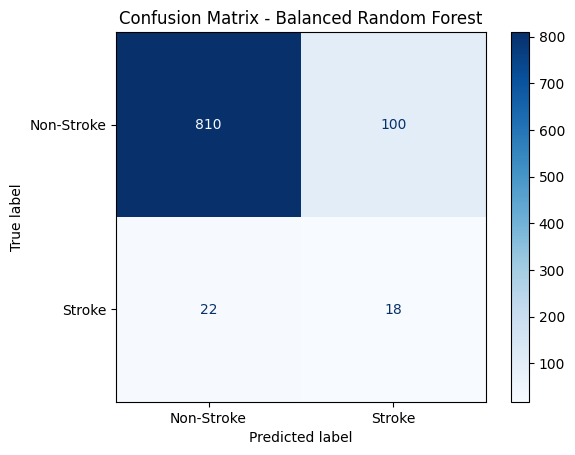

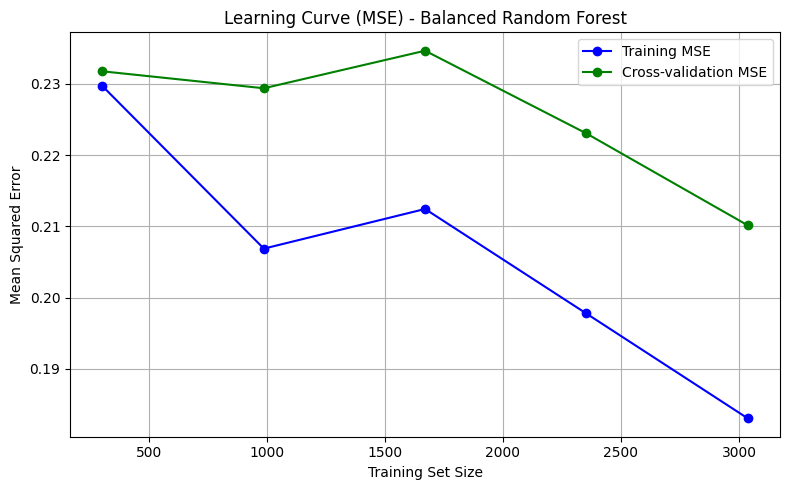

In [35]:
# Model: Balanced Random Forest
model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Probabilitas prediksi
y_probs = model.predict_proba(X_test)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    scores.append((t, f1))

# Pilih threshold terbaik
best_threshold, best_f1 = max(scores, key=lambda x: x[1])
print(f"\n Best Threshold: {best_threshold:.2f} dengan F1-Score: {best_f1:.4f}")

# Final Prediction menggunakan threshold terbaik
y_pred_final = (y_probs >= best_threshold).astype(int)

# === Evaluasi Akhir ===
print("\n=== Final Model Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Non-Stroke", "Stroke"]))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Stroke", "Stroke"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Balanced Random Forest")
plt.show()

# === Learning Curve (MSE) ===
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

train_mse = -np.mean(train_scores, axis=1)
test_mse = -np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mse, 'o-', label="Training MSE", color='blue')
plt.plot(train_sizes, test_mse, 'o-', label="Cross-validation MSE", color='green')
plt.title("Learning Curve (MSE) - Balanced Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Insight
Lalu disini saya mencoba Ensemble khusus Minoritas (Balancing Ensemble) dengan menggunakan data original, dan terlihat performa lebih baik dari model tanpa balancing. Dengan AUC ROC 0.67, dan recall Stroke 45%, model cukup baik untuk deteksi awal Stroke. Namun precision masih rendah sehingga perlu strategi untuk mengurangi false positive. Potensial jika fokus pada recall.

## KESIMPULAN

| Model      | Tanpa SMOTE (Default) | Dengan SMOTE (0.3) | Tuning Tanpa SMOTE | Balancing Ensemble (Tanpa SMOTE) |
| --------------- | --------------------- | ---------------------- | ------------------- | -------------------------------- |
| KNN             | R: 0.05, F1: 0.09      | R: 0.33, F1: 0.17       | R: 0.23, F1: 0.13    | -                                |
| Decision Tree   | R: 0.20, F1: 0.17      | R: 0.15, F1: 0.10       | R: 0.28, F1: 0.20    | -                                |
| Random Forest   | R: 0.03, F1: 0.05      | R: 0.05, F1: 0.06       | R: 0.35, F1: 0.18    | -                                |
| SVM             | R: 0.00, F1: 0.00      | R: 0.28, F1: 0.17       | R: 0.50, F1: 0.34    | -                                |
| Naive Bayes     | R: 0.57, F1: 0.31      | R: 0.70, F1: 0.24       | R: 0.55, F1: 0.34    | -                                |
| Ensemble        | -                      | -                       | -                    | R: 0.45, F1: 0.23                |
| ROC_AUC         | NB: 0.74, SVM: 0.50, RF: 0.51, DT: 0.58, KNN: 0.52              | NB: 0.76, SVM: 0.60, RF: 0.51, DT: 0.53, KNN: 0.61              | NB: 0.82, SVM: 0.54, RF: 0.73, DT: 0.48, KNN: 0.50 | 0.67                           |

- **Tanpa SMOTE:** Naive Bayes menunjukkan performa terbaik dalam hal Recall dan F1-Score untuk kelas Stroke, meskipun dengan Precision yang rendah. SVM gagal mengidentifikasi kasus Stroke sama sekali. Model lain juga memiliki performa yang buruk pada kelas minoritas.

- **Dengan SMOTE:** Penerapan SMOTE secara umum meningkatkan Recall untuk semua model, terutama Naive Bayes. Namun, Precision seringkali menurun. Naive Bayes tetap menjadi yang terbaik dalam hal Recall dan F1-Score untuk Stroke, serta ROC_AUC tertinggi.

- **Hyperparameter Tuning (Tanpa SMOTE):** Tuning meningkatkan performa beberapa model pada kelas Stroke, terutama SVM yang mengalami peningkatan signifikan dalam Recall dan F1-Score. Naive Bayes juga menunjukkan sedikit peningkatan dan mempertahankan ROC_AUC tertinggi.

- **Balancing Ensemble (Tanpa SMOTE):** Ensemble model ini berhasil mencapai Recall yang baik untuk Stroke tetapi dengan Precision yang sangat rendah, menghasilkan F1-Score yang moderat. ROC_AUC juga cukup baik.

Dengan mempertimbangkan ROC_AUC (kemampuan diskriminasi keseluruhan), Recall dan F1-Score untuk kelas Stroke (kemampuan identifikasi dan keseimbangan), serta akurasi, **Naive Bayes setelah hyperparameter tuning (tanpa SMOTE) muncul sebagai model terbaik secara keseluruhan.** Model ini menawarkan ROC_AUC tertinggi dan keseimbangan yang baik antara Recall dan Precision untuk kelas Stroke.